In [1]:
# 
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts/mge_classv2')
from mge_gen3 import MGEFitter
from astropy.io import fits
import numpy as np
import astropy.units as u   

# Load the images used

In [2]:
hst_mosaic =  fits.open(
        '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/HST/MAST_2026-03-10T1856/HST/u2j20e07t/u2j20e07t_drw.fits'
    )
jwst_mosaic = fits.open(
        '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_NOAGN_aligned.fits'
    )

# Load the MGE results from JWST

In [3]:
img_f200 = fits.open(
    '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_NOAGN_aligned.fits'
)[0].data

dust_mask = fits.open(
    '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/f200_mask_1.fits'
)[0].data

nan_mask = np.isnan(img_f200)
if np.any(nan_mask):
    print(f"Found {np.sum(nan_mask)} NaN pixels in the image. Replacing with 0 and adding to dust mask.")
    img_f200[nan_mask] = 0.0
    #dust_mask = dust_mask | nan_mask
    dust_mask[nan_mask] = 0

checkplot_dir = "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_NAGN_0deg_pa_positive_gauss"


runner = MGEFitter(
    img_f200,
    dust_mask,
    pixel_scale=0.031,
    subtract_sky=False,
    linear=False,
    ngauss=30,
    plot=True,
    checkplot_dir=checkplot_dir,
    cache_dir=checkplot_dir,
    prefix="sombrero_f200",
    contour_half_size_arcsec=10,
    contour_oversample=1,
    n_sectors=19,
    allow_negative=False,
    bulge_disk=False,
)

Found 79853476 NaN pixels in the image. Replacing with 0 and adding to dust mask.


 Pixels used: 5470365
 Peak img[j, k]: 7394, 7541
 Mean (j, k): 7413.62 7533.47
 Theta (deg): 0.8
 Astro PA (deg): 89.2
 Eps: 0.751
 Major axis (pix): 2979.7
Found galaxy center at public (x, y) = (7541.00, 7394.00), PA=89.17 deg, eps=0.751, theta=0.83 deg
No sky subtraction applied.


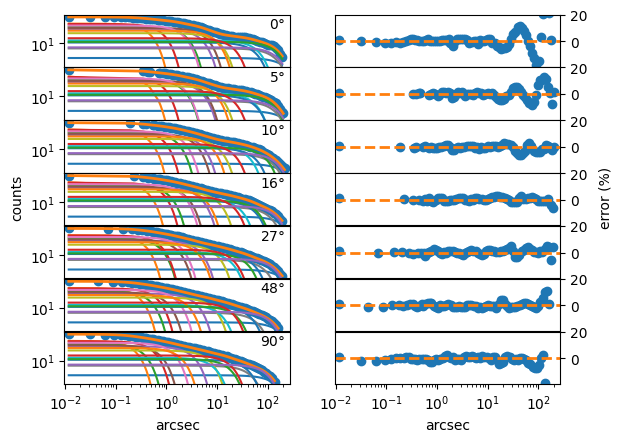

In [4]:
runner.run_fit().plot()
plt.pause(1)


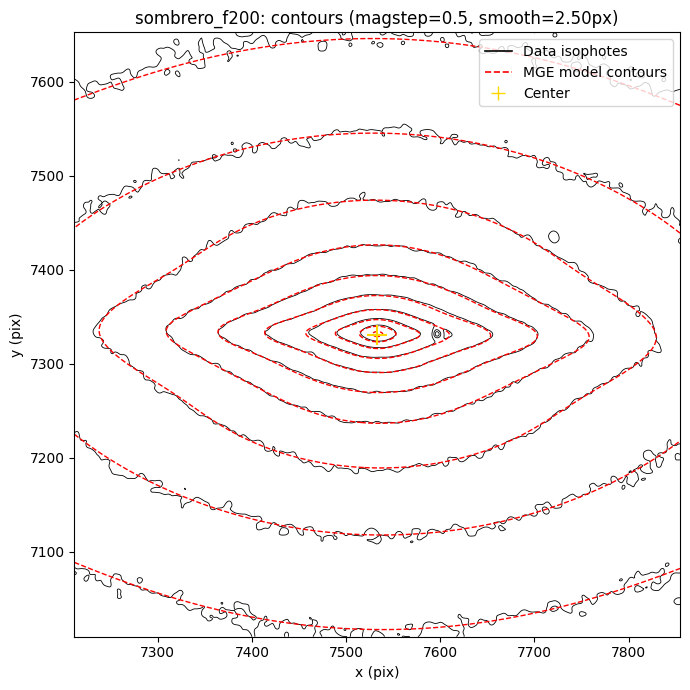

In [5]:
runner._plot_fit_contours(show=True, smoothing=2.5, magstep=0.5, minlevel=10)

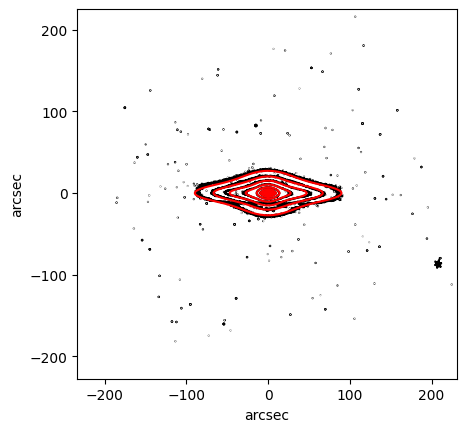

In [9]:
import mgefit as mge
m = runner.fit_result
mge.print_contours(img_f200, runner.pa
                  , runner.yc, runner.xc, m.sol, scale=runner.pixel_scale,
                       binning=10, sigmapsf=1, minlevel=10, magstep=0.5)

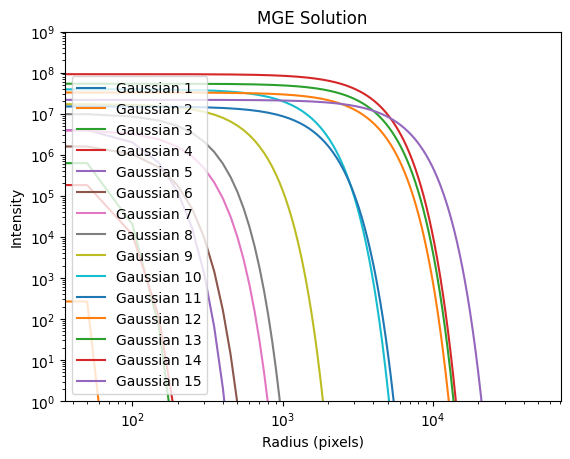

In [6]:
m = runner.fit_result
# Extract MGE solution arrays
sol = np.asarray(m.sol, dtype=float)
if sol.ndim != 2 or sol.shape[0] < 3:
    sol = np.vstack(m.sol)

total_counts = np.asarray(sol[0], dtype=float)
sigma_pix = np.asarray(sol[1], dtype=float)
q_obs = np.asarray(sol[2], dtype=float)

# plot the MGE solution
x = np.linspace(0, 0.5e5, 1000)
y = np.zeros_like(x)
for i in range(len(total_counts)):
    gaussian = total_counts[i] * np.exp(-0.5 * (x / sigma_pix[i])**2)
    plt.plot(x, gaussian, label=f'Gaussian {i+1}')
plt.xlabel('Radius (pixels)')
plt.ylabel('Intensity')
plt.title('MGE Solution')
# set log scale on both axes
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.ylim(1e0, 1e9)
plt.show()

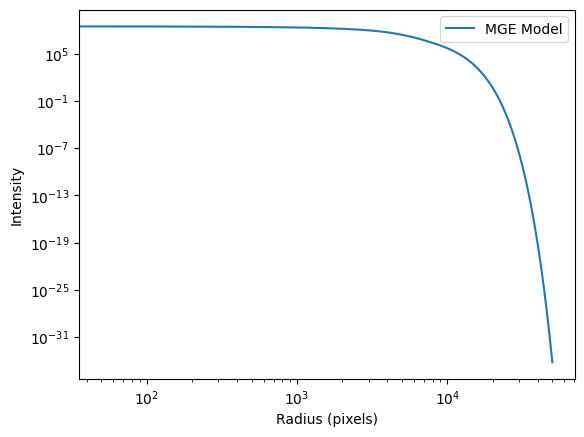

In [7]:
# build the radial model from the MGE solution
radial_model = np.zeros_like(x)
for i in range(len(total_counts)): # radial model is made by summing the gaussians together
    radial_model += total_counts[i] * np.exp(-0.5 * (x / sigma_pix[i])**2)

fig, ax = plt.subplots()
ax.plot(x, radial_model, label='MGE Model')
ax.set_xlabel('Radius (pixels)')
ax.set_ylabel('Intensity')
ax.set_xscale('log')
ax.set_yscale('log')
#ax.set_xlim(1e0, 1e5)
#ax.set_ylim(1e0, 1e9)
ax.legend()
plt.show()

# Now the same for the HST fit

In [8]:
img_f200 = fits.open(
        '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/HST/MAST_2026-03-10T1856/HST/u2j20e07t/u2j20e07t_drw.fits'
    )[1].data

dust_mask = fits.open(
    '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/hst_dust_mask_f814w.fits'
)[0].data

nan_mask = np.isnan(img_f200)
if np.any(nan_mask):
    print(f"Found {np.sum(nan_mask)} NaN pixels in the image. Replacing with 0 and adding to dust mask.")
    img_f200[nan_mask] = 0.0
    #dust_mask = dust_mask | nan_mask
    # make the NaN pixels be 0 in the dust mask (i.e. masked out)
    dust_mask[nan_mask] = 0


# make the dustmask boolean
#dust_mask = dust_mask.astype(bool)

checkplot_dir = "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MGE_HST_f814w"


runner_hst = MGEFitter(
    img_f200,
    dust_mask,
    dust_mask_is_bad=False,  # in this case, 1 means dust (bad), 0 means good
    pixel_scale= 0.1, # pixel scale for HST/WFPC2 in arcsec/pixel is 0.0996  
    subtract_sky=False,
    linear=False,
    ngauss=30,
    plot=True,
    checkplot_dir=checkplot_dir,
    cache_dir=checkplot_dir,
    prefix="sombrero_f814w",
    contour_half_size_arcsec=10,
    contour_oversample=1,
    n_sectors=19,
    allow_negative=False,
    bulge_disk=False,
    )


Found 10153710 NaN pixels in the image. Replacing with 0 and adding to dust mask.


In [9]:
res_hst =runner_hst.run_fit()

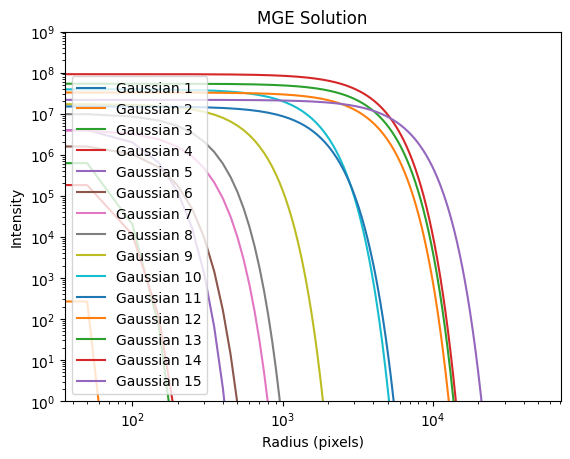

In [10]:

# Extract MGE solution arrays
sol_hst = np.asarray(res_hst.sol, dtype=float)
if sol_hst.ndim != 2 or sol_hst.shape[0] < 3:
    sol_hst = np.vstack(res_hst)

total_counts_hst = np.asarray(sol[0], dtype=float)
sigma_pix_hst = np.asarray(sol[1], dtype=float)
q_obs_hst = np.asarray(sol[2], dtype=float)

# plot the MGE solution
x = np.linspace(0, 0.5e5, 1000)
y = np.zeros_like(x)
for i in range(len(total_counts_hst)):
    gaussian = total_counts[i] * np.exp(-0.5 * (x / sigma_pix_hst[i])**2)
    plt.plot(x, gaussian, label=f'Gaussian {i+1}')
plt.xlabel('Radius (pixels)')
plt.ylabel('Intensity')
plt.title('MGE Solution')
# set log scale on both axes
plt.xscale('log')
plt.yscale('log')
plt.legend()
plt.ylim(1e0, 1e9)
plt.show()

In [11]:
runner.fit_result.sol

array([[1.13169435e+05, 4.45618140e+05, 1.96042762e+06, 4.60233533e+05,
        5.01544487e+06, 1.83680119e+06, 4.09445466e+06, 1.01542904e+07,
        1.71875588e+07, 3.92814971e+07, 1.50152113e+07, 3.27519206e+07,
        5.36927342e+07, 9.16415081e+07, 2.17201743e+07],
       [7.03886508e+00, 1.29910994e+01, 3.30619130e+01, 3.67788580e+01,
        7.37797885e+01, 9.26334212e+01, 1.44031889e+02, 1.68469644e+02,
        3.21073394e+02, 8.62209290e+02, 9.52093137e+02, 2.16408031e+03,
        2.29518336e+03, 2.34314009e+03, 3.61572458e+03],
       [5.14664054e-01, 6.48318699e-01, 6.13604149e-01, 1.47057173e-01,
        6.88434004e-01, 1.23227637e-01, 2.03518742e-01, 6.37379073e-01,
        8.83118448e-01, 7.01790094e-01, 1.41086147e-01, 3.32623626e-01,
        1.18814925e-01, 6.39248846e-01, 6.30693484e-01]])

# Now lets compare the two solutions

For this we need to scale the intensity accordingly, since we want to compare the model in the center, we cannot use the peak value there to normalize both. So we will integrate the mge in a given radius from the center in arcseconds, and match both at that radii. Then plot both fits together and their resiudals

In [12]:
def pixel_to_arcsec(sigma_pix, pixel_scale):
    """Convert MGE sigma from pixels to arcseconds."""
    return sigma_pix * pixel_scale

def model_to_physical_units(total_counts, sigma_pix, q_obs, pixel_scale):
    """Convert MGE model parameters to physical units."""
    sigma_arcsec = pixel_to_arcsec(sigma_pix, pixel_scale)
    # Assuming total_counts is in counts/pixel^2, convert to counts/arcsec^2
    total_counts_arcsec2 = total_counts / (pixel_scale**2)
    return total_counts_arcsec2, sigma_arcsec, q_obs

def mge_solution(total_counts, sigma_pix, q_obs, pixel_scale):
    """Convert MGE solution to physical units and return a function that allows the evaluation."""
    total_counts_arcsec2, sigma_arcsec, q_obs = model_to_physical_units(total_counts, sigma_pix, q_obs, pixel_scale)

    # build model function that takes radius in arcseconds and returns intensity in counts/arcsec^2
    def mge_model(radius_arcsec):
        intensity = np.zeros_like(radius_arcsec)
        for i in range(len(total_counts_arcsec2)):
            intensity += total_counts_arcsec2[i] * np.exp(-0.5 * (radius_arcsec / sigma_arcsec[i])**2)
        return intensity
    return mge_model

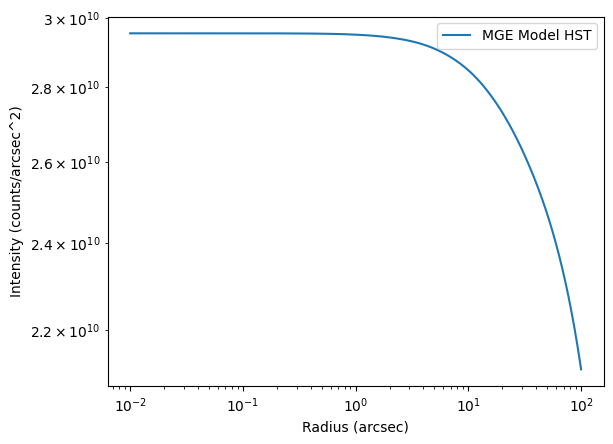

In [13]:
# test the mge model
mge_model_hst = mge_solution(total_counts_hst, sigma_pix_hst, q_obs_hst, pixel_scale=0.1)
radius_arcsec = np.linspace(0.01, 100, 1000)
intensity_hst = mge_model_hst(radius_arcsec)
fig, ax = plt.subplots()
ax.plot(radius_arcsec, intensity_hst, label='MGE Model HST')
ax.set_xlabel('Radius (arcsec)')
ax.set_ylabel('Intensity (counts/arcsec^2)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
plt.show()

Total flux in the region between 20 and 100 arcseconds: 1923328009030.686 counts
Total flux in the region between 20 and 100 arcseconds: 12683645112445.998 counts


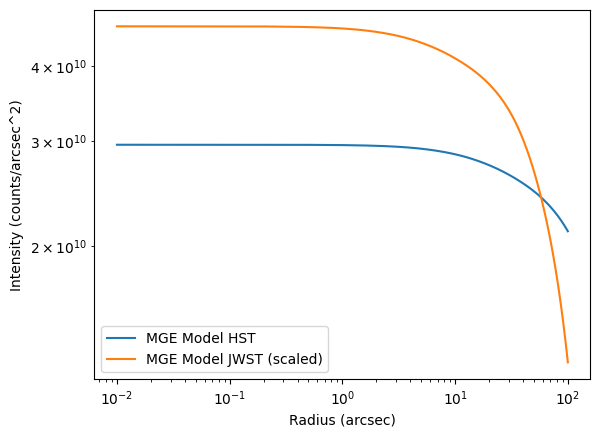

In [14]:
# now compute the integral of the mge model between 20 and 100 arcseconds to get the total flux in that region
from scipy.integrate import quad
def mge_integral(mge_model, r_min, r_max):
    """Integrate the MGE model between r_min and r_max in arcseconds."""
    result, error = quad(lambda r:  mge_model(r), r_min, r_max)
    return result
flux_hst = mge_integral(mge_model_hst, 20, 100)
print(f"Total flux in the region between 20 and 100 arcseconds: {flux_hst} counts")

# now the same for the JWST MGE model
mge_model_jwst = mge_solution(total_counts, sigma_pix, q_obs, pixel_scale=0.031)
intensity_jwst = mge_model_jwst(radius_arcsec)

# compute the integral for the JWST model
flux_jwst = mge_integral(mge_model_jwst, 20, 100)
print(f"Total flux in the region between 20 and 100 arcseconds: {flux_jwst} counts")

# plot the HST and JWST MGE models together using the scaling factor to convert the JWST model to the same units as the HST model
scaling_factor = flux_hst / flux_jwst
intensity_jwst_scaled = intensity_jwst * scaling_factor
fig, ax = plt.subplots()
ax.plot(radius_arcsec, intensity_hst, label='MGE Model HST')
ax.plot(radius_arcsec, intensity_jwst_scaled, label='MGE Model JWST (scaled)')
ax.set_xlabel('Radius (arcsec)')
ax.set_ylabel('Intensity (counts/arcsec^2)')
ax.set_xscale('log')
ax.set_yscale('log')
ax.legend()
plt.show()

In [15]:
runner_jwst = runner

In [16]:
# clear the runner
runner = None

In [18]:
import os
import numpy as np
import matplotlib.pyplot as plt


def _ensure_dir(path):
    if path is not None:
        os.makedirs(path, exist_ok=True)
    return path


def _get_runner_sol(runner):
    """
    Return MGE solution as arrays:
        total_counts, sigma_pix, q_obs

    Assumes runner.fit_result.sol has shape (3, N) or (N, 3).
    """
    sol = runner.fit_result.sol
    sol = np.asarray(sol)

    if sol.ndim != 2:
        raise ValueError("runner.fit_result.sol must be a 2D array")

    if sol.shape[0] == 3:
        counts, sigma_pix, q_obs = sol
    elif sol.shape[1] == 3:
        counts, sigma_pix, q_obs = sol.T
    else:
        raise ValueError(
            "Could not interpret runner.fit_result.sol. "
            "Expected shape (3, N) or (N, 3)."
        )

    return np.asarray(counts), np.asarray(sigma_pix), np.asarray(q_obs)


def _get_pixel_scale(runner):
    if not hasattr(runner, "pixel_scale"):
        raise AttributeError("Runner object has no attribute 'pixel_scale'")
    return float(runner.pixel_scale)


def mge_surface_brightness_aligned(x_arcsec, y_arcsec, runner, scale_factor=1.0):
    """
    Evaluate the 2D MGE surface brightness on a grid or points in the
    galaxy-aligned frame:

        x_arcsec : along major axis
        y_arcsec : along minor axis

    Parameters
    ----------
    x_arcsec, y_arcsec : array-like
        Coordinates in arcsec in the galaxy-aligned frame.
    runner : object
        Must contain:
            runner.fit_result.sol
            runner.pixel_scale
    scale_factor : float
        Multiplicative rescaling applied to all Gaussian amplitudes.

    Returns
    -------
    I : ndarray
        Surface brightness in arbitrary units / arcsec^2
        (up to the same overall normalization convention for both fits).
    """
    counts, sigma_pix, q_obs = _get_runner_sol(runner)
    pixscale = _get_pixel_scale(runner)

    sigma_arcsec = sigma_pix * pixscale

    x = np.asarray(x_arcsec)
    y = np.asarray(y_arcsec)

    I = np.zeros(np.broadcast(x, y).shape, dtype=float)

    for Lj, sj, qj in zip(counts * scale_factor, sigma_arcsec, q_obs):
        if sj <= 0 or qj <= 0:
            continue

        norm = Lj / (2.0 * np.pi * sj**2 * qj)
        expo = -0.5 * ((x / sj) ** 2 + (y / (sj * qj)) ** 2)
        I += norm * np.exp(expo)

    return I


def render_mge_aligned(runner, half_size_arcsec=10.0, step_arcsec=0.05, scale_factor=1.0):
    """
    Render the MGE on a square grid in the galaxy-aligned frame.
    """
    coords = np.arange(-half_size_arcsec, half_size_arcsec + step_arcsec, step_arcsec)
    xg, yg = np.meshgrid(coords, coords)
    img = mge_surface_brightness_aligned(xg, yg, runner, scale_factor=scale_factor)
    return coords, coords, img


def integrated_flux_in_annulus(runner, r_in=20.0, r_out=40.0, step_arcsec=0.1, scale_factor=1.0):
    """
    Numerically integrate the MGE in a circular annulus in the sky plane.
    Since the annulus is circular, this is well-defined directly from the 2D MGE.

    Returns total flux in the annulus.
    """
    half = r_out + 2.0 * step_arcsec
    coords = np.arange(-half, half + step_arcsec, step_arcsec)
    xg, yg = np.meshgrid(coords, coords)
    rr = np.sqrt(xg**2 + yg**2)

    img = mge_surface_brightness_aligned(xg, yg, runner, scale_factor=scale_factor)
    mask = (rr >= r_in) & (rr < r_out)

    pixel_area = step_arcsec**2
    return np.sum(img[mask]) * pixel_area


def compute_hst_to_jwst_scale(
    runner_jwst,
    runner_hst,
    r_in=20.0,
    r_out=40.0,
    step_arcsec=0.1,
):
    """
    Compute multiplicative factor such that:

        scaled_HST_flux(annulus) = JWST_flux(annulus)

    So:
        HST_scaled = scale * HST
    """
    flux_jwst = integrated_flux_in_annulus(
        runner_jwst, r_in=r_in, r_out=r_out, step_arcsec=step_arcsec, scale_factor=1.0
    )
    flux_hst = integrated_flux_in_annulus(
        runner_hst, r_in=r_in, r_out=r_out, step_arcsec=step_arcsec, scale_factor=1.0
    )

    if flux_hst <= 0:
        raise ValueError("HST annulus flux is <= 0, cannot compute scale factor.")

    scale = flux_jwst / flux_hst
    return scale, flux_jwst, flux_hst


def radial_profile_along_angle(runner, r_arcsec, phi_deg, scale_factor=1.0):
    """
    Profile along angle phi_deg in the galaxy-aligned frame:
        phi = 0 deg   -> major axis
        phi = 90 deg  -> minor axis
    """
    phi = np.deg2rad(phi_deg)
    x = r_arcsec * np.cos(phi)
    y = r_arcsec * np.sin(phi)
    return mge_surface_brightness_aligned(x, y, runner, scale_factor=scale_factor)


def compare_runner_mges(
    runner_jwst,
    runner_hst,
    *,
    annulus_r_in=20.0,
    annulus_r_out=40.0,
    annulus_step_arcsec=0.1,
    central_half_size_arcsec=10.0,
    central_step_arcsec=None,
    profile_rmax_arcsec=15.0,
    profile_npts=500,
    angles_deg=(0, 30, 60, 90),
    residual_type="fractional",   # "fractional" or "absolute"
    residual_floor_frac=1e-6,
    checkplots_path=None,
    prefix="jwst_hst_mge_compare",
    show=True,
    ):
    """
    Compare two MGE fits stored in runner objects.

    Outputs:
      - central map comparison
      - radial profiles at multiple angles
      - returns useful arrays and scale factor
    """
    _ensure_dir(checkplots_path)

    if central_step_arcsec is None:
        central_step_arcsec = min(
            _get_pixel_scale(runner_jwst),
            _get_pixel_scale(runner_hst),
        )

    # 1) Scale HST to JWST using the anulus photometry

    hst_scale, flux_jwst, flux_hst = compute_hst_to_jwst_scale(
        runner_jwst,
        runner_hst,
        r_in=annulus_r_in,
        r_out=annulus_r_out,
        step_arcsec=annulus_step_arcsec,
    )


    # 2) Render central maps in aligned coordinates

    x, y, img_jwst = render_mge_aligned(
        runner_jwst,
        half_size_arcsec=central_half_size_arcsec,
        step_arcsec=central_step_arcsec,
        scale_factor=1.0,
    )
    _, _, img_hst_scaled = render_mge_aligned(
        runner_hst,
        half_size_arcsec=central_half_size_arcsec,
        step_arcsec=central_step_arcsec,
        scale_factor=hst_scale,
    )

    extent = [x.min(), x.max(), y.min(), y.max()]
    
    # Adjust the type of resiudal, here suporting fractional, absolute, and ratio residuals
    if residual_type == "fractional":
        floor = residual_floor_frac * np.nanmax(img_jwst)
        denom = np.where(img_jwst > floor, img_jwst, np.nan)
        residual_map = (img_jwst - img_hst_scaled) / denom
        residual_label = r"(JWST - scaled HST) / JWST"
    elif residual_type == "absolute":
        residual_map = img_jwst - img_hst_scaled
        residual_label = r"JWST - scaled HST"
    elif residual_type == "ratio":
        floor = residual_floor_frac * np.nanmax(img_jwst)
        denom = np.where(img_jwst > floor, img_jwst, np.nan)
        residual_map = img_hst_scaled / denom
        residual_label = r"scaled HST / JWST"
    else:
        raise ValueError("residual_type must be 'fractional', 'absolute', or 'ratio'")

    # Use log display for the model maps
    eps = 1e-300
    log_jwst = np.log10(np.maximum(img_jwst, eps))
    log_hst = np.log10(np.maximum(img_hst_scaled, eps))

    vmin = np.nanpercentile(
        np.concatenate([log_jwst.ravel(), log_hst.ravel()]),
        5
    )
    vmax = np.nanpercentile(
        np.concatenate([log_jwst.ravel(), log_hst.ravel()]),
        99.8
    )

    if residual_type == "fractional":
        rv = np.nanpercentile(np.abs(residual_map[np.isfinite(residual_map)]), 99)
        rv = max(rv, 0.05)
        rmin, rmax = -rv, rv
    elif residual_type == "ratio":
        rv = np.nanpercentile(np.abs(residual_map[np.isfinite(residual_map)]), 90)
        rmin, rmax = -rv, rv
    else:
        rv = np.nanpercentile(np.abs(residual_map[np.isfinite(residual_map)]), 99)
        rmin, rmax = -rv, rv

    fig_map, axes = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

    im0 = axes[0].imshow(
        log_jwst, origin="lower", extent=extent, vmin=vmin, vmax=vmax, cmap="viridis"
    )
    axes[0].set_title("JWST MGE")
    axes[0].set_xlabel("Major-axis coordinate [arcsec]")
    axes[0].set_ylabel("Minor-axis coordinate [arcsec]")
    plt.colorbar(im0, ax=axes[0], label=r"log$_{10}$ surface brightness")

    im1 = axes[1].imshow(
        log_hst, origin="lower", extent=extent, vmin=vmin, vmax=vmax, cmap="viridis"
    )
    axes[1].set_title(f"Scaled HST MGE\n(scale = {hst_scale:.6g})")
    axes[1].set_xlabel("Major-axis coordinate [arcsec]")
    axes[1].set_ylabel("Minor-axis coordinate [arcsec]")
    plt.colorbar(im1, ax=axes[1], label=r"log$_{10}$ surface brightness")

    im2 = axes[2].imshow(
        residual_map, origin="lower", extent=extent, vmin=rmin, vmax=rmax, cmap="RdBu_r"
    )
    axes[2].set_title("Residual")
    axes[2].set_xlabel("Major-axis coordinate [arcsec]")
    axes[2].set_ylabel("Minor-axis coordinate [arcsec]")
    plt.colorbar(im2, ax=axes[2], label=residual_label)

    for ax in axes:
        ax.set_aspect("equal")

    # fig_map.suptitle(
    #     f"MGE comparison in central region\n"
    #     f"HST scaled to JWST using circular annulus {annulus_r_in:.1f}\"–{annulus_r_out:.1f}\"",
    #     y=1.02
    # )

    if checkplots_path is not None:
        fig_map.savefig(
            os.path.join(checkplots_path, f"{prefix}_central_residual_map.png"),
            dpi=200,
            bbox_inches="tight"
        )

    # ------------------------------------------------------------------
    # 3) Radial profiles at multiple angles
    # ------------------------------------------------------------------
    r = np.linspace(0.0, profile_rmax_arcsec, profile_npts)
    nang = len(angles_deg)

    fig_prof, axes = plt.subplots(
        2, nang,
        figsize=(4.2 * nang, 6.0),
        sharex="col",
        gridspec_kw={"height_ratios": [3, 1]},
        constrained_layout=True
    )

    if nang == 1:
        axes = np.array(axes).reshape(2, 1)

    profile_dict = {}

    for i, phi in enumerate(angles_deg):
        prof_jwst = radial_profile_along_angle(
            runner_jwst, r, phi_deg=phi, scale_factor=1.0
        )
        prof_hst = radial_profile_along_angle(
            runner_hst, r, phi_deg=phi, scale_factor=hst_scale
        )

        if residual_type == "fractional":
            floor = residual_floor_frac * np.nanmax(prof_jwst)
            denom = np.where(prof_jwst > floor, prof_jwst, np.nan)
            prof_resid = (prof_jwst - prof_hst) / denom
        else:
            prof_resid = prof_jwst - prof_hst

        profile_dict[phi] = {
            "r_arcsec": r,
            "jwst": prof_jwst,
            "hst_scaled": prof_hst,
            "residual": prof_resid,
        }

        ax_top = axes[0, i]
        ax_bot = axes[1, i]

        ax_top.plot(r, prof_jwst, label="JWST", lw=2)
        ax_top.plot(r, prof_hst, label="scaled HST", lw=2, ls="--")
        ax_top.set_yscale("log")
        ax_top.set_title(rf"$\phi = {phi}^\circ$")
        ax_top.set_ylabel("Surface brightness")
        ax_top.grid(alpha=0.3)

        ax_bot.plot(r, prof_resid, lw=1.8)
        ax_bot.axhline(0.0, color="k", ls=":", lw=1)
        ax_bot.set_xlabel("Radius [arcsec]")
        ax_bot.set_ylabel("Residual")
        ax_bot.grid(alpha=0.3)

    axes[0, 0].legend(loc="best")

    # fig_prof.suptitle(
    #     #f"Radial comparison of MGE fits\n"
    #     #f"Angles measured from the major axis in the galaxy-aligned frame",
    #     y=1.02
    # )

    if checkplots_path is not None:
        fig_prof.savefig(
            os.path.join(checkplots_path, f"{prefix}_radial_profiles.png"),
            dpi=200,
            bbox_inches="tight"
        )

    if show:
        plt.show()
    else:
        plt.close(fig_map)
        plt.close(fig_prof)

    return {
        "hst_to_jwst_scale": hst_scale,
        "jwst_annulus_flux": flux_jwst,
        "hst_annulus_flux_unscaled": flux_hst,
        "central_x_arcsec": x,
        "central_y_arcsec": y,
        "central_jwst": img_jwst,
        "central_hst_scaled": img_hst_scaled,
        "central_residual": residual_map,
        "profiles": profile_dict,
        "fig_map": fig_map,
        "fig_profiles": fig_prof,
    }

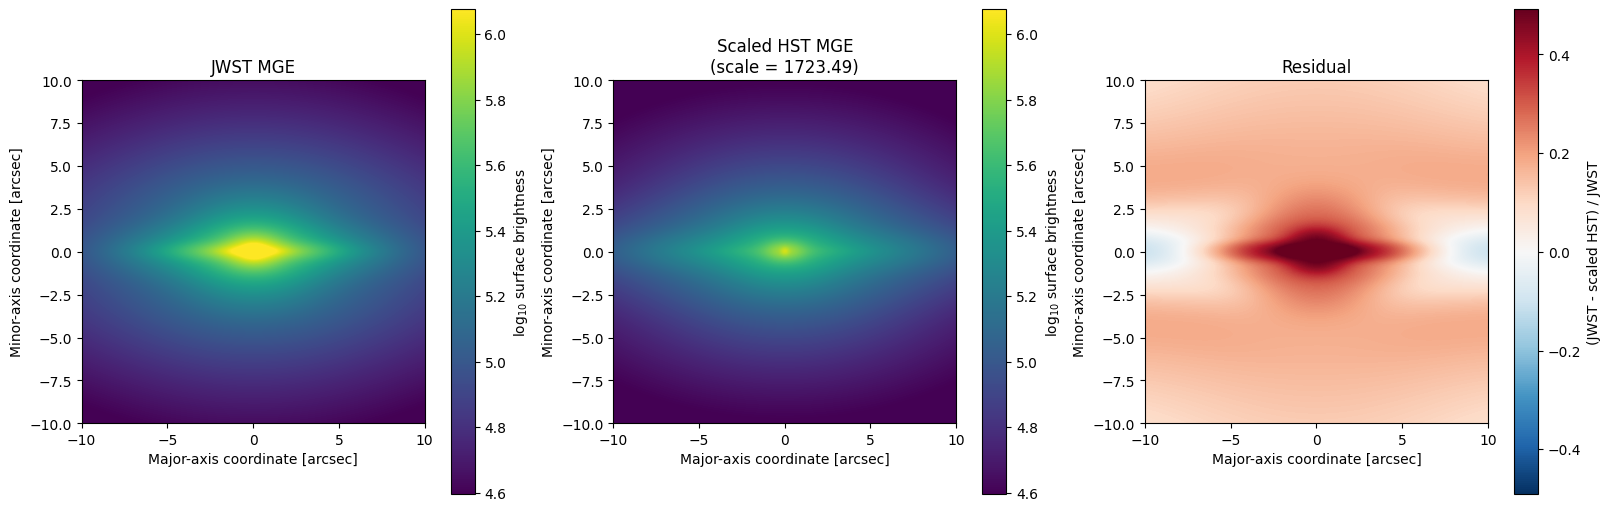

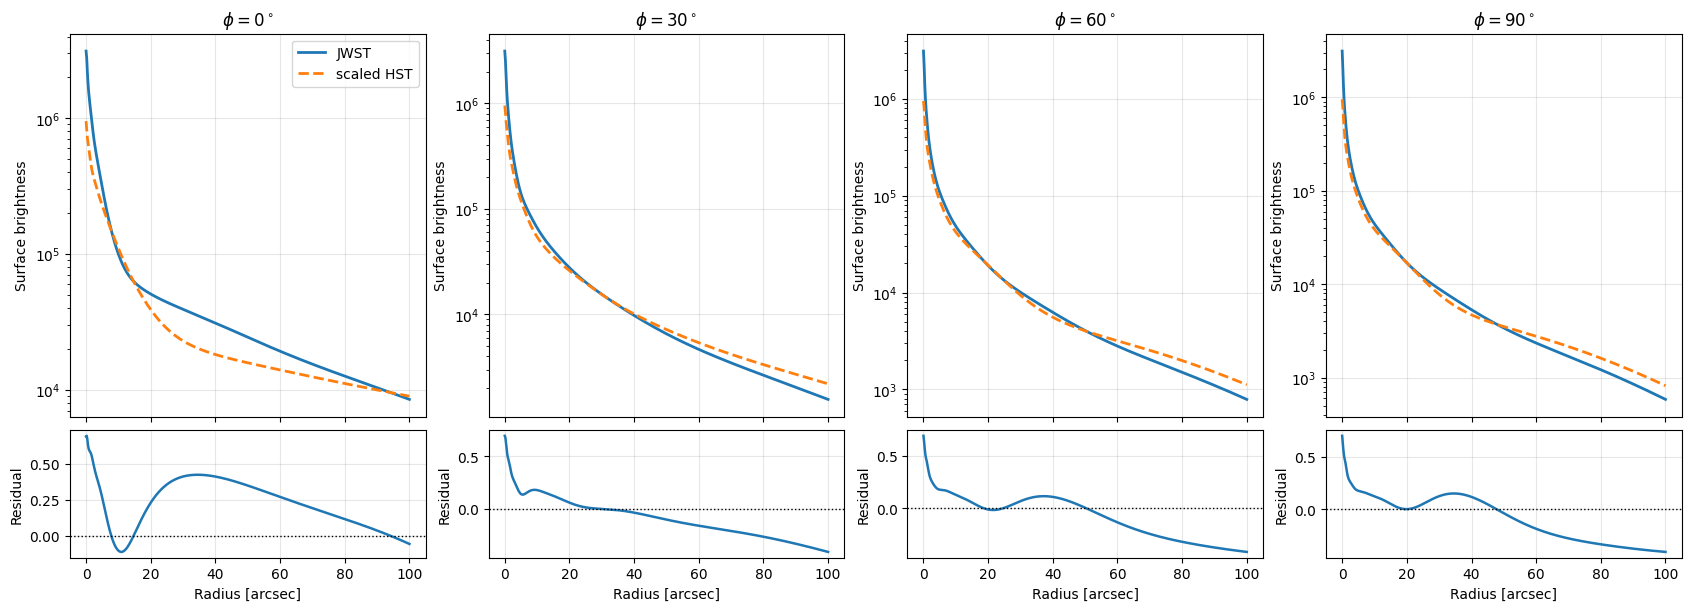

HST -> JWST scale factor: 1723.492813859184
JWST annulus flux: 167024907.4957221
HST annulus flux (unscaled): 96910.70722930711


In [23]:
out = compare_runner_mges(
    runner_jwst,
    runner_hst,
    annulus_r_in=20,
    annulus_r_out=100.0,
    annulus_step_arcsec=0.1,
    central_half_size_arcsec=10.0,
    central_step_arcsec=0.03,          # or None to use the finer runner pixel scale
    profile_rmax_arcsec=100.0,
    profile_npts=500,
    angles_deg=(0, 30, 60, 90),
    residual_type="fractional",        # or "absolute"
    checkplots_path="/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MGE_comparison_NAGN_to_HST_f814w",
    prefix="jwst_vs_hst_restrict",
    show=True,
)

print("HST -> JWST scale factor:", out["hst_to_jwst_scale"])
print("JWST annulus flux:", out["jwst_annulus_flux"])
print("HST annulus flux (unscaled):", out["hst_annulus_flux_unscaled"])

# ratio map

In [39]:

annulus_r_in=20
annulus_r_out=100.0
annulus_step_arcsec=0.1
central_half_size_arcsec=3.5
central_step_arcsec=0.03     # or None to use the finer runner pixel scale
profile_rmax_arcsec=10.0
profile_npts=500
angles_deg=(0, 30, 60, 90)
residual_type="ratio"        # or "absolute"
checkplots_path="/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MGE_comparison_checkplots"
prefix="jwst_vs_hst_restrict"
show=True

residual_floor_frac=1e-6
"""
Compare two MGE fits stored in runner objects.

Outputs:
    - central map comparison
    - radial profiles at multiple angles
    - returns useful arrays and scale factor
"""
_ensure_dir(checkplots_path)

if central_step_arcsec is None:
    central_step_arcsec = min(
        _get_pixel_scale(runner_jwst),
        _get_pixel_scale(runner_hst),
    )

# 1) Scale HST to JWST using the anulus photometry

hst_scale, flux_jwst, flux_hst = compute_hst_to_jwst_scale(
    runner_jwst,
    runner_hst,
    r_in=annulus_r_in,
    r_out=annulus_r_out,
    step_arcsec=annulus_step_arcsec,
)


# 2) Render central maps in aligned coordinates

x, y, img_jwst = render_mge_aligned(
    runner_jwst,
    half_size_arcsec=central_half_size_arcsec,
    step_arcsec=central_step_arcsec,
    scale_factor=1.0,
)
_, _, img_hst_scaled = render_mge_aligned(
    runner_hst,
    half_size_arcsec=central_half_size_arcsec,
    step_arcsec=central_step_arcsec,
    scale_factor=hst_scale,
)

extent = [x.min(), x.max(), y.min(), y.max()]

# Adjust the type of resiudal, here suporting fractional, absolute, and ratio residuals
if residual_type == "fractional":
    floor = residual_floor_frac * np.nanmax(img_jwst)
    denom = np.where(img_jwst > floor, img_jwst, np.nan)
    residual_map = (img_jwst - img_hst_scaled) / denom
    residual_label = r"(JWST - scaled HST) / JWST"
elif residual_type == "absolute":
    residual_map = img_jwst - img_hst_scaled
    residual_label = r"JWST - scaled HST"
elif residual_type == "ratio":
    floor = residual_floor_frac * np.nanmax(img_jwst)
    denom = np.where(img_jwst > floor, img_jwst, np.nan)
    residual_map = img_hst_scaled / denom
    residual_label = r"scaled HST / JWST"
else:
    raise ValueError("residual_type must be 'fractional', 'absolute', or 'ratio'")

# Use log display for the model maps
eps = 1e-300
log_jwst = np.log10(np.maximum(img_jwst, eps))
log_hst = np.log10(np.maximum(img_hst_scaled, eps))

vmin = np.nanpercentile(
    np.concatenate([log_jwst.ravel(), log_hst.ravel()]),
    5
)
vmax = np.nanpercentile(
    np.concatenate([log_jwst.ravel(), log_hst.ravel()]),
    99.8
)

if residual_type == "fractional":
    rv = np.nanpercentile(np.abs(residual_map[np.isfinite(residual_map)]), 99)
    rv = max(rv, 0.05)
    rmin, rmax = -rv, rv
elif residual_type == "ratio":
    rv = np.nanpercentile(np.abs(residual_map[np.isfinite(residual_map)]), 90)
    rmin, rmax = -rv, rv
else:
    rv = np.nanpercentile(np.abs(residual_map[np.isfinite(residual_map)]), 99)
    rmin, rmax = -rv, rv


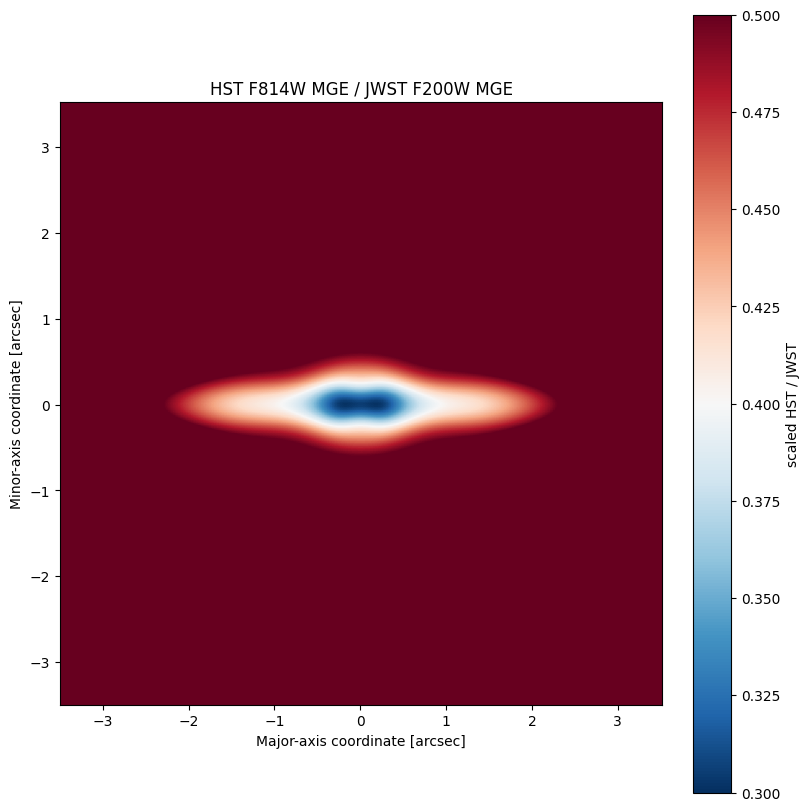

: 

In [ ]:
fig_map, axes = plt.subplots(1,1, figsize=(8, 8), constrained_layout=True)
extent = [x.min(), x.max(), y.min(), y.max()]

im2 = axes.imshow(
    residual_map, origin="lower", extent=extent, vmin=0.3, vmax=0.5, cmap="RdBu_r"
)
    # im2 = axes[2].imshow(
    #     residual_map, origin="lower", extent=extent, vmin=0.2, vmax=1, cmap="RdBu_r"
    # )
axes.set_title("HST F814W MGE / JWST F200W MGE")
axes.set_xlabel("Major-axis coordinate [arcsec]")
axes.set_ylabel("Minor-axis coordinate [arcsec]")
plt.colorbar(im2, ax=axes, label=residual_label)

axes.set_aspect("equal")


In [76]:
# save hst mge parameters to a text file
counts, sigma_pix, q_obs = _get_runner_sol(runner_hst)
# save csv with columns: total_counts, sigma_pix, q_obs
import pandas as pd
df_hst = pd.DataFrame({
    "total_counts": counts,
    "sigma_pix": sigma_pix,
    "q_obs": q_obs,
})
df_hst.to_csv("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MGE_HST_f814w/mge_parameters_hst.csv", index=False)

# same with jwst
counts, sigma_pix, q_obs = _get_runner_sol(runner_jwst)
df_jwst = pd.DataFrame({
    "total_counts": counts,
    "sigma_pix": sigma_pix,
    "q_obs": q_obs,
})
df_jwst.to_csv("/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/MGE_HST_f814w/mge_parameters_jwst.csv", index=False)
